# Engine: The 16D Oscilloscope — angular content and subspace occupancy

**File:** `ValaQuenta/modules/angular_rank/`  
**ValaQuenta wiki:** [wiki/angular_rank.md](../../wiki/angular_rank.md)  
**Ainulindale wiki:** `Ainulindale/wiki/86_the_16d_oscilloscope.md`

> *"we don't remove items from a list while iterating over it... that's an amateur move...
> that is definitely iterating over a field while modifying it. by the nature of code,
> that's going to drift and possibly seize the engine down the line"*  
> — Cody Michael Allison, 2026-08-15

## One instrument, two applications

| # | question | function |
|---|---|---|
| 1 | how much **direction** survives once the common mode is removed? | `angular_residual` |
| 2 | which dimensions are populated, at what **rank**? | `occupancy`, `numerical_rank` |
| 3 | does it reach `ker(L_a)` — what the internal channel **cannot** produce? | `null_occupancy` |

**Question 3 is the internal/external provenance test. Question 1 is the
language-agnostic stress test. They are the same measurement.**


In [1]:
import sys, os, math
sys.path.insert(0, os.path.abspath('../../..'))
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})

from ValaQuenta.modules.angular_rank import (
    SEDENION_DIM, CALIBRATION, Datum, datum, is_datum, sight, embed_log_bands,
    occupancy, singular_spectrum, numerical_rank, orthonormal_span,
    common_direction, angular_residual, score_against_calibration,
    left_mul_matrix, null_space, verify_null_space,
    null_occupancy, null_occupancy_baseline,
    external_component, principal_angles, bearing, angular_report,
)
rng = np.random.default_rng(20260815)
print('dimension:', SEDENION_DIM)


dimension: 16


## 1. The honest check — the {4,8,4} split, derived not asserted

`a = (e₁ + e₁₀)/√2`, Assessor (1,2), strut 3. Agreement with
`Null-Space-of-the-Zero-Divisor.md` is a **CHECK, not an input**.


In [2]:
v = verify_null_space()
for k, val in v.items():
    print(f'{k:<20} {val}')


assessor             (1, 2)
strut                3
nullity              4
rank                 12
singular_counts      {'sqrt2': 4, 'one': 8, 'zero': 4}
expected_counts      {'sqrt2': 4, 'one': 8, 'zero': 4}
matches_published    True


### `L_a` cross-checked against box_kite's independent `multiply()`

One multiplication table in the repo. This module borrows it rather than
reimplementing it, and then verifies the borrowing.


In [3]:
from ValaQuenta.modules.box_kite import multiply
a = [0.0]*16; a[1] = a[10] = 1/math.sqrt(2)
L = left_mul_matrix(a)
x = rng.standard_normal(16)
print('L_a x == a*x :', np.allclose(L @ x, np.array(multiply(a, list(x)))))

ker = np.array(null_space(a)['basis'])
print('a * ker  == 0 :', all(np.allclose(multiply(a, list(b)), 0, atol=1e-12) for b in ker))
print('nullity       :', ker.shape[0])


L_a x == a*x : True
a * ker  == 0 : True
nullity       : 4


## 2. THE DATUM DISCIPLINE

`datum()` is the **only** way into the module. Every other entry point
refuses a live sequence — because measuring a span that the measured process
is concurrently growing is iterate-while-modify, and it does not raise. It
**drifts**, until the internal span covers the kernel and the instrument
reports *all quiet* forever.


In [4]:
try:
    angular_residual([[1.0]*16])
except TypeError as ex:
    print('REFUSED:', ex)


REFUSED: angular_residual() requires an Datum, got list. Call datum(field, label) first -- measuring a live field is iterate-while-modify and will drift silently.


In [5]:
field = rng.standard_normal((40, 16)).tolist()
e0 = datum(field, 'demo')
print(e0)
print('stamp stable on re-datum :', datum(field, 'demo').stamp == e0.stamp)

f2 = [r[:] for r in field]; f2[0][0] += 1e-9
print('stamp moves on a 1e-9 change:', datum(f2, 'demo').stamp != e0.stamp)


<Datum 'demo' n=40 dim=16 stamp=c3ac2e5f752f>
stamp stable on re-datum : True
stamp moves on a 1e-9 change: True


### Mutation is DATED, not forbidden

`bearing()` measures drift **between** two datums, so a measurement never
straddles a write. `rank_delta > 0` means the internal span grew and any earlier
external-occupancy result taken against the older datum is now **stale**.

Phase 27.3 is the bounded reference: net winding +0.0000 turns, non-accumulating,
held by the gearing rather than computed. Growth that does not level off is the
seizure warning.


In [6]:
A = rng.standard_normal((50, 16)); A[:, 4:] = 0.0     # internal span: 4 dims
before = datum(A.tolist(), 'internal_t0')
B = np.vstack([A, rng.standard_normal((20, 16))])     # thinking threads grew it
after  = datum(B.tolist(), 'internal_t1')

p = bearing(before, after)
for k in ('rank_before','rank_after','rank_delta','largest_principal_angle','stale_measurements'):
    print(f'{k:<26} {p[k]}')


rank_before                4
rank_after                 16
rank_delta                 12
largest_principal_angle    3.6500241499888574e-08
stale_measurements         True


## 3. MANDATORY NULL 1 — the isotropic kernel baseline is exactly 4/16

An isotropic random field already puts `nullity/dim` of its energy in `ker(L_a)`.

> ⚠ A raw kernel fraction near **0.25** is evidence of **nothing**.
> Only the **excess** is a signal.


In [7]:
b = null_occupancy_baseline(a)
for k, val in b.items():
    print(f'{k:<20} {val}')


nullity              4
analytic_baseline    0.25
measured_baseline    0.25096808363015466
agreement            True
rule                 report EXCESS over baseline, never the raw fraction


In [8]:
# built inside the kernel vs isotropic
K = np.array(null_space(a)['basis'])
inside = datum((rng.standard_normal((40, 4)) @ K).tolist(), 'in_kernel')
iso    = datum(rng.standard_normal((200, 16)).tolist(), 'isotropic')

for name, ep in (('in kernel', inside), ('isotropic', iso)):
    r = null_occupancy(ep, a)
    print(f"{name:<12} fraction {r['fraction']:.4f}  excess {r['excess']:+.4f}  reportable {r['reportable']}")


in kernel    fraction 1.0000  excess +0.7500  reportable True
isotropic    fraction 0.2431  excess -0.0069  reportable False


## 4. Angular content — and MANDATORY NULL 2, the embedding caveat

A scalar has magnitude and no direction. Text entering 0_RB as one scalar lands
on e₀ and scores **exactly 0** (Phase 27.1). The phonetic face is the only
existing construction with real angular content: **0.402** (Phase 27.2).

> ⚠ These constants were measured on the **phonetic face** embedding.
> They **do not transfer** to any other embedding.


In [9]:
for name, ref in CALIBRATION.items():
    print(f"{name:<20} residual {ref['angular_residual']:.4f}   cos {ref['collapse_cos']:.4f}")
    print(f"{'':20} {ref['note_']}")


scalar_address       residual 0.0000   cos 1.0000
                     by construction -- text enters 0_RB as one scalar (Phase 27.1)
character_encoder    residual 0.0002   cos 0.9998
                     Phase 23 encoder -- collapsed onto the common direction
phonetic_face        residual 0.4020   cos 0.9109
                     the only existing construction with real angular content


In [10]:
scalar_field = [[c]*16 for c in (1.0, 2.0, 3.0, 4.0, 5.0)]
for name, ep in (('scalar',   datum(scalar_field, 'scalar')),
                 ('isotropic', iso)):
    r = angular_residual(ep)
    print(f"{name:<10} residual {r['mean_angular_residual']:.6f}   collapse cos {r['mean_collapse_cos']:.4f}")


scalar     residual 0.000000   collapse cos 1.0000
isotropic  residual 0.961219   collapse cos 0.0896


In [11]:
s = score_against_calibration(angular_residual(iso)['mean_angular_residual'])
print(s['verdict'])
print('nearest reference:', s['nearest_reference'])
print('CAVEAT:', s['caveat'])


HIGHLY ANGULAR -- exceeds every English reference measured
nearest reference: phonetic_face
CAVEAT: CALIBRATION IS EMBEDDING-SPECIFIC (phonetic face, Phase 27.2). Does not transfer to embed_log_bands or any other embedding.


## 5. The language-agnostic embedding

`embed_log_bands()` makes no phoneme inventory, no lexicon, and no assumption of
human vocal-tract bandwidth — so it is usable on cetacean recordings, where energy
runs well past 100 kHz and any English-derived band layout would be a category error.

It L2-normalises, discarding loudness on purpose: **this instrument measures
direction.**


In [12]:
# synthetic broadband frames at a cetacean-appropriate sample rate
sr = 192000.0
frames = []
for _ in range(60):
    spec = np.abs(rng.standard_normal(4096))**2
    spec[300:900] *= rng.uniform(1.0, 6.0)      # a moving band of emphasis
    frames.append(embed_log_bands(spec, sample_rate=sr))

ep = datum(frames, 'synthetic_broadband')
occ = occupancy(ep)
print('participation ratio: %.2f of 16' % occ['participation_ratio'])
print('rank:', numerical_rank(ep)['rank'])
print('angular residual: %.4f' % angular_residual(ep)['mean_angular_residual'])


participation ratio: 3.58 of 16
rank: 16
angular residual: 0.1516


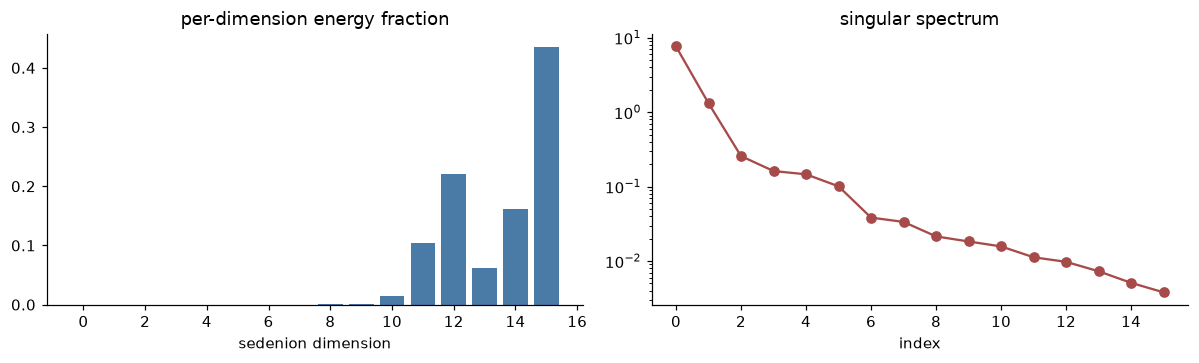

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].bar(range(16), occ['per_dimension'], color='#4a7ba7')
ax[0].set_title('per-dimension energy fraction'); ax[0].set_xlabel('sedenion dimension')
ax[1].plot(singular_spectrum(ep), 'o-', color='#a74a4a')
ax[1].set_title('singular spectrum'); ax[1].set_xlabel('index'); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()


## 6. The stress test, one card

Every entry carries the datum stamp it was read from, and the embedding it is
relative to.

> ⚠ **No measurement is reportable without its datum.**


In [14]:
card = angular_report(ep, a=a, internal=before, embedding='log_bands_192k')
print('label      ', card['label'])
print('stamp      ', card['stamp'][:24], '...')
print('embedding  ', card['embedding'])
print('rank       ', card['rank']['rank'], 'of', card['rank']['full_rank'])
print('residual   %.4f' % card['angular']['mean_angular_residual'])
print('kernel     fraction %.4f  excess %+.4f  reportable %s' % (
      card['null_occupancy']['fraction'], card['null_occupancy']['excess'],
      card['null_occupancy']['reportable']))
print('external   fraction outside internal span %.4f' % card['external']['fraction_outside'])
print()
print('CAVEAT:', card['calibration']['caveat'])


label       synthetic_broadband
stamp       f2fd86683a9f5808950579fb ...
embedding   log_bands_192k
rank        16 of 16
residual   0.1516
kernel     fraction 0.4436  excess +0.1936  reportable True
external   fraction outside internal span 1.0000

CAVEAT: CALIBRATION IS EMBEDDING-SPECIFIC (phonetic face, Phase 27.2). Does not transfer to embed_log_bands or any other embedding.


## 7. The silent failure mode — read this before trusting a zero

> ⚠ `null_occupancy()` returning ~0 is **ambiguous**. It means *either* no external
> signal *or* the ear is wired **through** `L_a` instead of summed in downstream of
> it — in which case the external component is annihilated identically and the
> instrument is blind, **with no error raised**.

Demonstrated below: a genuinely external signal, routed through `L_a`, becomes
indistinguishable from silence.


In [15]:
ext_signal = rng.standard_normal((60, 16))
direct  = datum(ext_signal.tolist(), 'ear_direct')
through = datum((ext_signal @ left_mul_matrix(a).T).tolist(), 'ear_through_L_a')

for name, epx in (('summed downstream', direct), ('routed THROUGH L_a', through)):
    r = null_occupancy(epx, a)
    print(f"{name:<22} kernel fraction {r['fraction']:.6f}  excess {r['excess']:+.6f}")
print()
print('Both are external. Only one is visible. Verify the wiring separately.')


summed downstream      kernel fraction 0.276333  excess +0.026333
routed THROUGH L_a     kernel fraction 0.000000  excess -0.250000

Both are external. Only one is visible. Verify the wiring separately.


## Open

| item | status |
|---|---|
| does a real ear injection land in `ker(L_a)` at all? | **untested** — the provenance test depends on it entirely |
| ear summed downstream of `L_a`, not through it | wiring unverified; fails silently if wrong |
| VAPMIP `monad.c`: one `G` under one `pthread_mutex_t G.lock` | **blocker** — provenance destroyed at write |
| cetacean corpus | none in repo; instrument calibrated and waiting |
| an embedding-independent angular statistic | none; every number here is embedding-relative |

---

*What this instrument cannot support, and must not be made to: any claim about what
a signal **means**. That is a `beta`, it needs a source position, and no instrument
on this bench supplies one. See `Operating-L_(I|O).md` §1.*
